# LANGKAH 0: INSTALASI DAN IMPORT LIBRARY
## Menginstal library yang diperlukan dari Hugging Face dan Scikit-learn.

In [3]:
!pip install wandb transformers datasets scikit-learn scikit-multilearn emoji torch --quiet

import pandas as pd
import torch
import torch.nn as nn
import emoji
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from transformers import AutoTokenizer, AutoModel, AutoConfig, Trainer, TrainingArguments
from datasets import Dataset
from skmultilearn.model_selection import iterative_train_test_split
from dataclasses import dataclass
from transformers.tokenization_utils_base import PaddingStrategy, PreTrainedTokenizerBase
from typing import Any, Callable, Dict, List, NewType, Optional, Tuple, Union
import random
import os

In [4]:
# Fungsi untuk mengunci Random Seed
def set_seed(seed_value=42):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed_value)

# Set seed global
SEED = 42
set_seed(SEED)
print(f"Random seed telah dikunci ke: {SEED}")

Random seed telah dikunci ke: 42


# LANGKAH 1: MEMUAT DATASET
## Pastikan file 'dataset.csv' sudah ada di environment Anda.

In [ ]:
try:
    df = pd.read_csv('https://raw.githubusercontent.com/gikirima/TEA-emoji/refs/heads/v2.0/Dataset/dataset_emoji_only.csv')
    print("Dataset 'dataset.csv' berhasil dimuat.")
except FileNotFoundError:
    print("Error: File 'dataset.csv' tidak ditemukan.")
    print("Silakan unggah file tersebut terlebih dahulu.")
    # Hentikan eksekusi jika file tidak ada
    exit()

Dataset 'dataset.csv' berhasil dimuat.


# LANGKAH 2: EKSTRAKSI EMOJI & PEMBUATAN VOCABULARY
## [MODIFIED] Langkah ini diubah untuk membuat vocabulary emoji terpisah, bukan untuk menambahkannya ke tokenizer BERT.

In [6]:
print("\nMemindai dataset untuk mencari emoji unik...")
unique_emojis = set()
for text in df['text'].dropna():
    text_str = str(text)
    for character in text_str:
        if emoji.is_emoji(character):
            unique_emojis.add(character)

# [NEW] Membuat mapping dari emoji ke ID integer. Tambahkan token PAD untuk padding.
emoji_list = sorted(list(unique_emojis)) # Urutkan agar konsisten
emoji_to_id = {em: i for i, em in enumerate(emoji_list, 1)}
emoji_to_id['<PAD>'] = 0 # ID 0 untuk padding
id_to_emoji = {i: em for em, i in emoji_to_id.items()}
EMOJI_VOCAB_SIZE = len(emoji_to_id)
EMOJI_PAD_ID = emoji_to_id['<PAD>']


print(f"Ditemukan {len(unique_emojis)} emoji unik.")
print(f"Ukuran vocabulary emoji (termasuk <PAD>): {EMOJI_VOCAB_SIZE}")


Memindai dataset untuk mencari emoji unik...
Ditemukan 1040 emoji unik.
Ukuran vocabulary emoji (termasuk <PAD>): 1041


# LANGKAH 3: DEFINISI MODEL KUSTOM (EARLY FUSION)
## mendefinisikan arsitektur model baru untuk menggabungkan fitur BERT dan fitur emoji.

In [7]:
class BertEmojiFusionModel(nn.Module):
    """
    Model kustom yang menggabungkan output dari IndoBERT dengan embedding emoji.
    """
    def __init__(self, model_name, num_labels, emoji_vocab_size, emoji_emb_dim=256, dropout_rate=0.2):
        super().__init__()
        self.num_labels = num_labels

        # 1. Muat model BERT dasar
        self.bert = AutoModel.from_pretrained(model_name)
        bert_hidden_size = self.bert.config.hidden_size

        # 2. Buat layer embedding khusus untuk emoji
        self.emoji_embeddings = nn.Embedding(emoji_vocab_size, emoji_emb_dim, padding_idx=EMOJI_PAD_ID)

        # 3. Definisikan classifier head (MLP)
        # Inputnya adalah gabungan dari [CLS] token BERT dan vektor emoji
        self.classifier = nn.Sequential(
            nn.Linear(bert_hidden_size + emoji_emb_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_labels)
        )

        # [NEW] Simpan problem_type untuk kompatibilitas dengan Hugging Face Trainer
        self.config = self.bert.config
        self.config.problem_type = "multi_label_classification"


    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        emoji_ids: torch.Tensor,
        labels: Optional[torch.Tensor] = None
    ):
        # 1. Dapatkan output dari BERT
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # Ambil representasi token [CLS] (output untuk seluruh kalimat)
        cls_output = bert_outputs.last_hidden_state[:, 0, :]

        # 2. Dapatkan embedding emoji dan hitung rata-ratanya
        emoji_mask = (emoji_ids != EMOJI_PAD_ID).float()
        emoji_embs = self.emoji_embeddings(emoji_ids)

        # Kalikan dengan mask untuk memastikan token PAD menjadi vektor nol
        emoji_embs = emoji_embs * emoji_mask.unsqueeze(-1)

        # Hitung rata-rata embedding, hindari pembagian dengan nol jika tidak ada emoji
        sum_embs = torch.sum(emoji_embs, dim=1)
        num_emojis = torch.sum(emoji_mask, dim=1).unsqueeze(-1)
        mean_emoji_embs = sum_embs / (num_emojis + 1e-9) # Tambah epsilon untuk stabilitas

        # 3. Gabungkan (concatenate) fitur BERT dan fitur emoji
        combined_features = torch.cat((cls_output, mean_emoji_embs), dim=1)

        # 4. Lewatkan fitur gabungan ke classifier untuk mendapatkan logits
        logits = self.classifier(combined_features)

        # 5. Hitung loss jika labels diberikan (selama training)
        loss = None
        if labels is not None:
            loss_fct = nn.BCEWithLogitsLoss()
            loss = loss_fct(logits, labels.float())

        # Kembalikan output dalam format yang dikenali oleh Trainer
        return (loss, logits) if loss is not None else (logits,)

# --- Inisialisasi Model ---
model_name = "indobenchmark/indobert-base-p1"
label_columns = ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']
num_labels = len(label_columns)
EMOJI_EMBEDDING_DIM = 128 # Dimensi embedding untuk emoji, bisa di-tune

print(f"\nMemuat tokenizer '{model_name}'...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f"Menginisialisasi model kustom 'BertEmojiFusionModel'...")
model = BertEmojiFusionModel(
    model_name=model_name,
    num_labels=num_labels,
    emoji_vocab_size=EMOJI_VOCAB_SIZE,
    emoji_emb_dim=EMOJI_EMBEDDING_DIM
)

print("Model dan tokenizer siap digunakan.")
# [MODIFIED] Bagian `resize_token_embeddings` dihapus karena kita tidak lagi menambahkan emoji ke vocab BERT.


Memuat tokenizer 'indobenchmark/indobert-base-p1'...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Menginisialisasi model kustom 'BertEmojiFusionModel'...


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Model dan tokenizer siap digunakan.


# LANGKAH 4: PERSIAPAN DATASET UNTUK HUGGING FACE
## [MODIFIED] Mengubah format, melakukan split, dan memproses data untuk model kustom.

In [8]:
# --- Pembagian Data (Sama seperti sebelumnya) ---
print("\nMemulai pembagian dataset dengan metode iterative_train_test_split...")
X = df['text'].to_numpy().reshape(-1, 1)
y = df[label_columns].to_numpy()

X_train_val, y_train_val, X_test, y_test = iterative_train_test_split(X, y, test_size=0.2)
X_train, y_train, X_val, y_val = iterative_train_test_split(X_train_val, y_train_val, test_size=0.2)

df_train = pd.DataFrame(X_train.flatten(), columns=['text'])
for i, col in enumerate(label_columns): df_train[col] = y_train[:, i]

df_val = pd.DataFrame(X_val.flatten(), columns=['text'])
for i, col in enumerate(label_columns): df_val[col] = y_val[:, i]

df_test = pd.DataFrame(X_test.flatten(), columns=['text'])
for i, col in enumerate(label_columns): df_test[col] = y_test[:, i]

print("\nMengubah format DataFrame menjadi Hugging Face Dataset...")
train_dataset_hf = Dataset.from_pandas(df_train)
eval_dataset_hf = Dataset.from_pandas(df_val)
test_dataset_hf = Dataset.from_pandas(df_test)

# --- [NEW] Fungsi Preprocessing Terpadu ---
def preprocess_data(examples):
    # 1. Tokenisasi teks untuk BERT
    tokenized_output = tokenizer(
        examples["text"], padding=False, truncation=True, max_length=128
    )

    # 2. Ekstraksi dan pemetaan emoji ke ID
    all_emoji_ids = []
    texts = [str(t) for t in examples["text"]]
    for text in texts:
        # Temukan emoji dalam teks dan ubah ke ID, jika tidak ada di vocab, abaikan
        ids = [emoji_to_id.get(char) for char in text if emoji.is_emoji(char) and char in emoji_to_id]
        # Hapus None values jika ada emoji yang tidak dikenali
        ids = [id for id in ids if id is not None]
        if not ids:
            ids = [EMOJI_PAD_ID] # Jika tidak ada emoji, beri satu token PAD
        all_emoji_ids.append(ids)

    # 3. Format label
    labels = [[float(examples[label][i]) for label in label_columns] for i in range(len(texts))]

    tokenized_output["emoji_ids"] = all_emoji_ids
    tokenized_output["labels"] = labels
    return tokenized_output

print("\nMelakukan tokenisasi, ekstraksi emoji, dan pemformatan label pada semua set data...")
train_dataset = train_dataset_hf.map(preprocess_data, batched=True, remove_columns=train_dataset_hf.column_names)
eval_dataset = eval_dataset_hf.map(preprocess_data, batched=True, remove_columns=eval_dataset_hf.column_names)
test_dataset = test_dataset_hf.map(preprocess_data, batched=True, remove_columns=test_dataset_hf.column_names)


print("\n--- Pembagian Data Selesai ---")
print(f"Jumlah data latih (train): {len(train_dataset)}")
print(f"Jumlah data validasi (validation): {len(eval_dataset)}")
print(f"Jumlah data uji (test): {len(test_dataset)}")




Memulai pembagian dataset dengan metode iterative_train_test_split...


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]


Mengubah format DataFrame menjadi Hugging Face Dataset...

Melakukan tokenisasi, ekstraksi emoji, dan pemformatan label pada semua set data...


Map:   0%|          | 0/89312 [00:00<?, ? examples/s]

Map:   0%|          | 0/22090 [00:00<?, ? examples/s]

Map:   0%|          | 0/28012 [00:00<?, ? examples/s]


--- Pembagian Data Selesai ---
Jumlah data latih (train): 89312
Jumlah data validasi (validation): 22090
Jumlah data uji (test): 28012


In [9]:
# --- HITUNG CLASS WEIGHTS (Penanganan Imbalance) ---
# Kita hitung bobot dari df_train karena dataset HF sudah diproses

# Ambil array label (0 atau 1) dari DataFrame df_train
labels_array = df_train[label_columns].to_numpy()

# Hitung jumlah sampel positif dan negatif per label
num_positives = labels_array.sum(axis=0)
num_negatives = labels_array.shape[0] - num_positives

# Rumus: pos_weight = jumlah_negatif / jumlah_positif
# Ditambah epsilon (1e-5) untuk mencegah error jika ada label kosong
pos_weights_tensor = torch.tensor((num_negatives / (num_positives + 1e-5)), dtype=torch.float)

# Pindahkan ke GPU agar kompatibel saat training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weights_tensor = pos_weights_tensor.to(device)

print("\nClass Weights (pos_weight) berhasil dihitung:")
for label, weight in zip(label_columns, pos_weights_tensor):
    print(f"- {label}: {weight.item():.4f}")


Class Weights (pos_weight) berhasil dihitung:
- joy: 0.5821
- trust: 1.2768
- fear: 15.3246
- surprise: 17.5295
- sadness: 3.1791
- disgust: 11.3632
- anger: 20.7834
- anticipation: 1.9377


## Visualisasi distribusi label


Menghitung dan menampilkan distribusi label di setiap set data...


/tmp/ipython-input-2030676071.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_df.index, y='Train', data=dist_df, ax=axes[0], palette='viridis')
/tmp/ipython-input-2030676071.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_df.index, y='Validation', data=dist_df, ax=axes[1], palette='viridis')
/tmp/ipython-input-2030676071.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_df.index, y='Test', data=dist_df, ax=axes[2], palette='viridis')


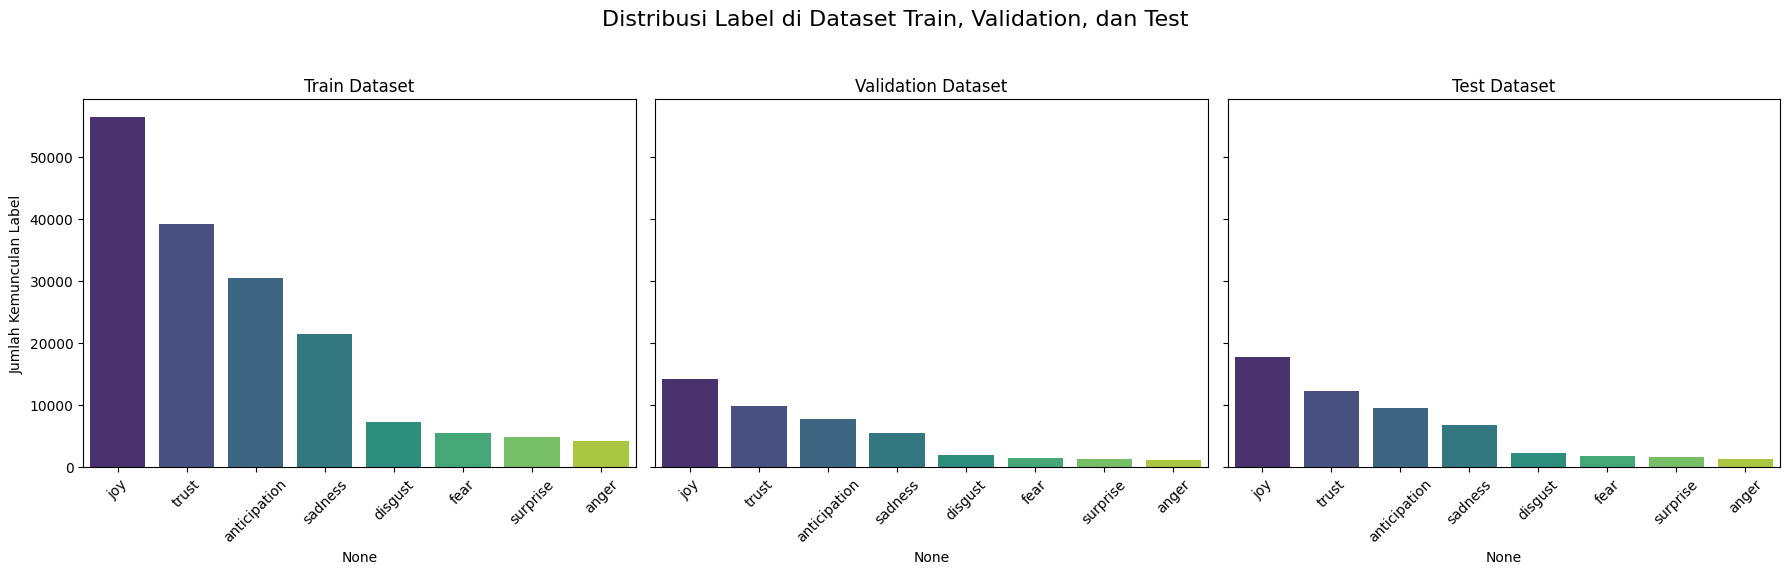


Distribusi label berhasil ditampilkan.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\nMenghitung dan menampilkan distribusi label di setiap set data...")

def get_label_distribution(dataset_hf, label_columns):
    """Menghitung jumlah kemunculan setiap label dalam dataset Hugging Face."""
    df = dataset_hf.to_pandas()
    distribution = df[label_columns].sum().sort_values(ascending=False)
    return distribution

# Hitung distribusi untuk setiap set
train_label_dist = get_label_distribution(train_dataset_hf, label_columns)
eval_label_dist = get_label_distribution(eval_dataset_hf, label_columns)
test_label_dist = get_label_distribution(test_dataset_hf, label_columns)

# Buat DataFrame gabungan untuk plotting
dist_df = pd.DataFrame({
    'Train': train_label_dist,
    'Validation': eval_label_dist,
    'Test': test_label_dist
})

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Distribusi Label di Dataset Train, Validation, dan Test', fontsize=16)

# Plot Train
sns.barplot(x=dist_df.index, y='Train', data=dist_df, ax=axes[0], palette='viridis')
axes[0].set_title('Train Dataset')
axes[0].set_ylabel('Jumlah Kemunculan Label')
axes[0].tick_params(axis='x', rotation=45)

# Plot Validation
sns.barplot(x=dist_df.index, y='Validation', data=dist_df, ax=axes[1], palette='viridis')
axes[1].set_title('Validation Dataset')
axes[1].set_ylabel('') # Hide y-label as it's shared
axes[1].tick_params(axis='x', rotation=45)

# Plot Test
sns.barplot(x=dist_df.index, y='Test', data=dist_df, ax=axes[2], palette='viridis')
axes[2].set_title('Test Dataset')
axes[2].set_ylabel('') # Hide y-label as it's shared
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print("\nDistribusi label berhasil ditampilkan.")

# LANGKAH 4.5: MEMBUAT DATA COLLATOR KUSTOM
## Collator ini akan menangani padding untuk `input_ids` dan `emoji_ids` secara bersamaan.

In [11]:
@dataclass
class CustomDataCollator:
    tokenizer: PreTrainedTokenizerBase
    padding: Union[bool, str, PaddingStrategy] = True
    max_length: Optional[int] = None
    pad_to_multiple_of: Optional[int] = None

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, Any]:
        # Pisahkan label, emoji_ids, dan fitur lainnya
        labels = [feature.pop("labels") for feature in features]
        emoji_ids = [feature.pop("emoji_ids") for feature in features]

        # Gunakan padding bawaan tokenizer untuk input_ids, attention_mask, dll.
        batch = self.tokenizer.pad(
            features,
            padding=self.padding,
            max_length=self.max_length,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt",
        )

        # Padding manual untuk emoji_ids
        max_emoji_len = max(len(ids) for ids in emoji_ids)
        padded_emoji_ids = [ids + [EMOJI_PAD_ID] * (max_emoji_len - len(ids)) for ids in emoji_ids]

        # Tambahkan kembali data yang sudah diproses ke batch
        batch["labels"] = torch.tensor(labels, dtype=torch.float)
        batch["emoji_ids"] = torch.tensor(padded_emoji_ids, dtype=torch.long)

        return batch

# Inisialisasi data collator
data_collator = CustomDataCollator(tokenizer=tokenizer)

# LANGKAH 5: MENDEFINISIKAN METRIK EVALUASI
## Fungsi ini akan menghitung metrik performa model saat evaluasi.

In [12]:
def compute_metrics(p):
    logits, labels = p
    # Menggunakan sigmoid karena ini adalah klasifikasi multi-label
    preds_proba = torch.sigmoid(torch.tensor(logits))
    # Threshold 0.5 untuk menentukan apakah label aktif (1) atau tidak (0)
    preds = (preds_proba > 0.5).int().numpy()
    labels = labels.astype(int)

    f1_macro = f1_score(labels, preds, average='macro')
    f1_micro = f1_score(labels, preds, average='micro')
    precision_micro = precision_score(labels, preds, average='micro')
    recall_micro = recall_score(labels, preds, average='micro')

    return {
        'f1_macro': f1_macro,
        'f1_micro': f1_micro,
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'accuracy': accuracy_score(labels, preds), # Accuracy berbasis exact match
    }

# LANGKAH 6: KONFIGURASI DAN PROSES TRAINING
## Menentukan argumen pelatihan dan memulai proses fine-tuning.

In [13]:
# 1. Custom Trainer Khusus untuk Model Kustom (Tuple Output)
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)

        # [PENTING] Karena BertEmojiFusionModel mengembalikan tuple (loss, logits)
        # Kita harus mengambil logits dari indeks ke-1.
        # Jika arsitektur berubah jadi dict, kita pakai .get('logits')
        if isinstance(outputs, tuple):
            logits = outputs[1]
        elif hasattr(outputs, 'logits'):
            logits = outputs.logits
        else:
            logits = outputs

        # Menggunakan BCEWithLogitsLoss dengan pos_weight
        loss_fct = nn.BCEWithLogitsLoss(pos_weight=pos_weights_tensor)
        loss = loss_fct(logits, labels.float())

        return (loss, outputs) if return_outputs else loss

In [14]:
import wandb
from google.colab import userdata

# Login to WANDB
# Make sure you have added your WANDB API key to Colab secrets with the name WANDB_API_KEY
try:
    wandb_api_key = userdata.get('WANDB_API_KEY')
    if wandb_api_key:
        wandb.login(key=wandb_api_key)
        print("WANDB login successful.")
    else:
        print("WANDB_API_KEY not found in Colab secrets. Please add it to use WANDB logging.")
except Exception as e:
    print(f"An error occurred during WANDB login: {e}")

# --- Inisialisasi WANDB ---
wandb.init(
    project="TEA_V2",  # Nama project di W&B
    name="EF_Concat_run_1",              # Nama run, ubah jadi training_2, dst.
)

training_args = TrainingArguments(
    output_dir="./results_fusion",
    eval_strategy="steps",
    save_strategy="steps",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=250,
    eval_steps=1500,
    save_steps=1500,
    save_total_limit=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    learning_rate=5e-5,
    warmup_steps=500,
    weight_decay=0.01,
    fp16=True, # Membutuhkan GPU dengan Tensor Cores (T4, V100, A100)
    report_to="wandb", # Ubah ke "wandb" jika Anda menggunakan W&B
    seed=SEED,
    data_seed=SEED
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator, # [MODIFIED] Menggunakan data collator kustom
    compute_metrics=compute_metrics
)

print("\nMemulai proses fine-tuning model (Early Fusion) dengan Class Weights & Seed...")
trainer.train()

print("\nPelatihan selesai.")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: farhanprwnto (farhanprwnto-universitas-sumatera-utara) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WANDB login successful.


/tmp/ipython-input-3453859566.py:45: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.



Memulai proses fine-tuning model (Early Fusion) dengan Class Weights & Seed...


Step,Training Loss,Validation Loss,F1 Macro,F1 Micro,Precision Micro,Recall Micro,Accuracy
1500,0.656400,0.602803,0.645204,0.771551,0.714424,0.838608,0.464871


KeyboardInterrupt: 

# LANGKAH 7: EVALUASI AKHIR
## Mengevaluasi model terbaik pada data uji.


=== 1. PENCARIAN DYNAMIC THRESHOLD (MENGGUNAKAN VALIDATION SET) ===


Step,Training Loss,Validation Loss,F1 Macro,F1 Micro,Precision Micro,Recall Micro,Accuracy
1500,0.656400,0.602803,0.645204,0.771551,0.714424,0.838608,0.464871


Mengoptimalkan threshold per label...
          Label  Optimized Threshold
0           joy                 0.45
1         trust                 0.60
2          fear                 0.90
3      surprise                 0.70
4       sadness                 0.60
5       disgust                 0.55
6         anger                 0.75
7  anticipation                 0.45

=== 2. EVALUASI TEST SET (DENGAN DYNAMIC THRESHOLD) ===

[Global Metrics]
Accuracy (Exact Match): 0.5079
F1 Macro Average      : 0.6552
F1 Micro Average      : 0.7901

[Detailed Metrics Per Class]
       Label  Threshold  Precision  Recall  F1-Score
         joy       0.45     0.8732  0.9163    0.8942
       trust       0.60     0.8407  0.8789    0.8594
        fear       0.90     0.7350  0.7006    0.7174
    surprise       0.70     0.3054  0.3287    0.3166
     sadness       0.60     0.7280  0.8199    0.7712
     disgust       0.55     0.5435  0.5509    0.5472
       anger       0.75     0.4223  0.4161    0.4192
anticip

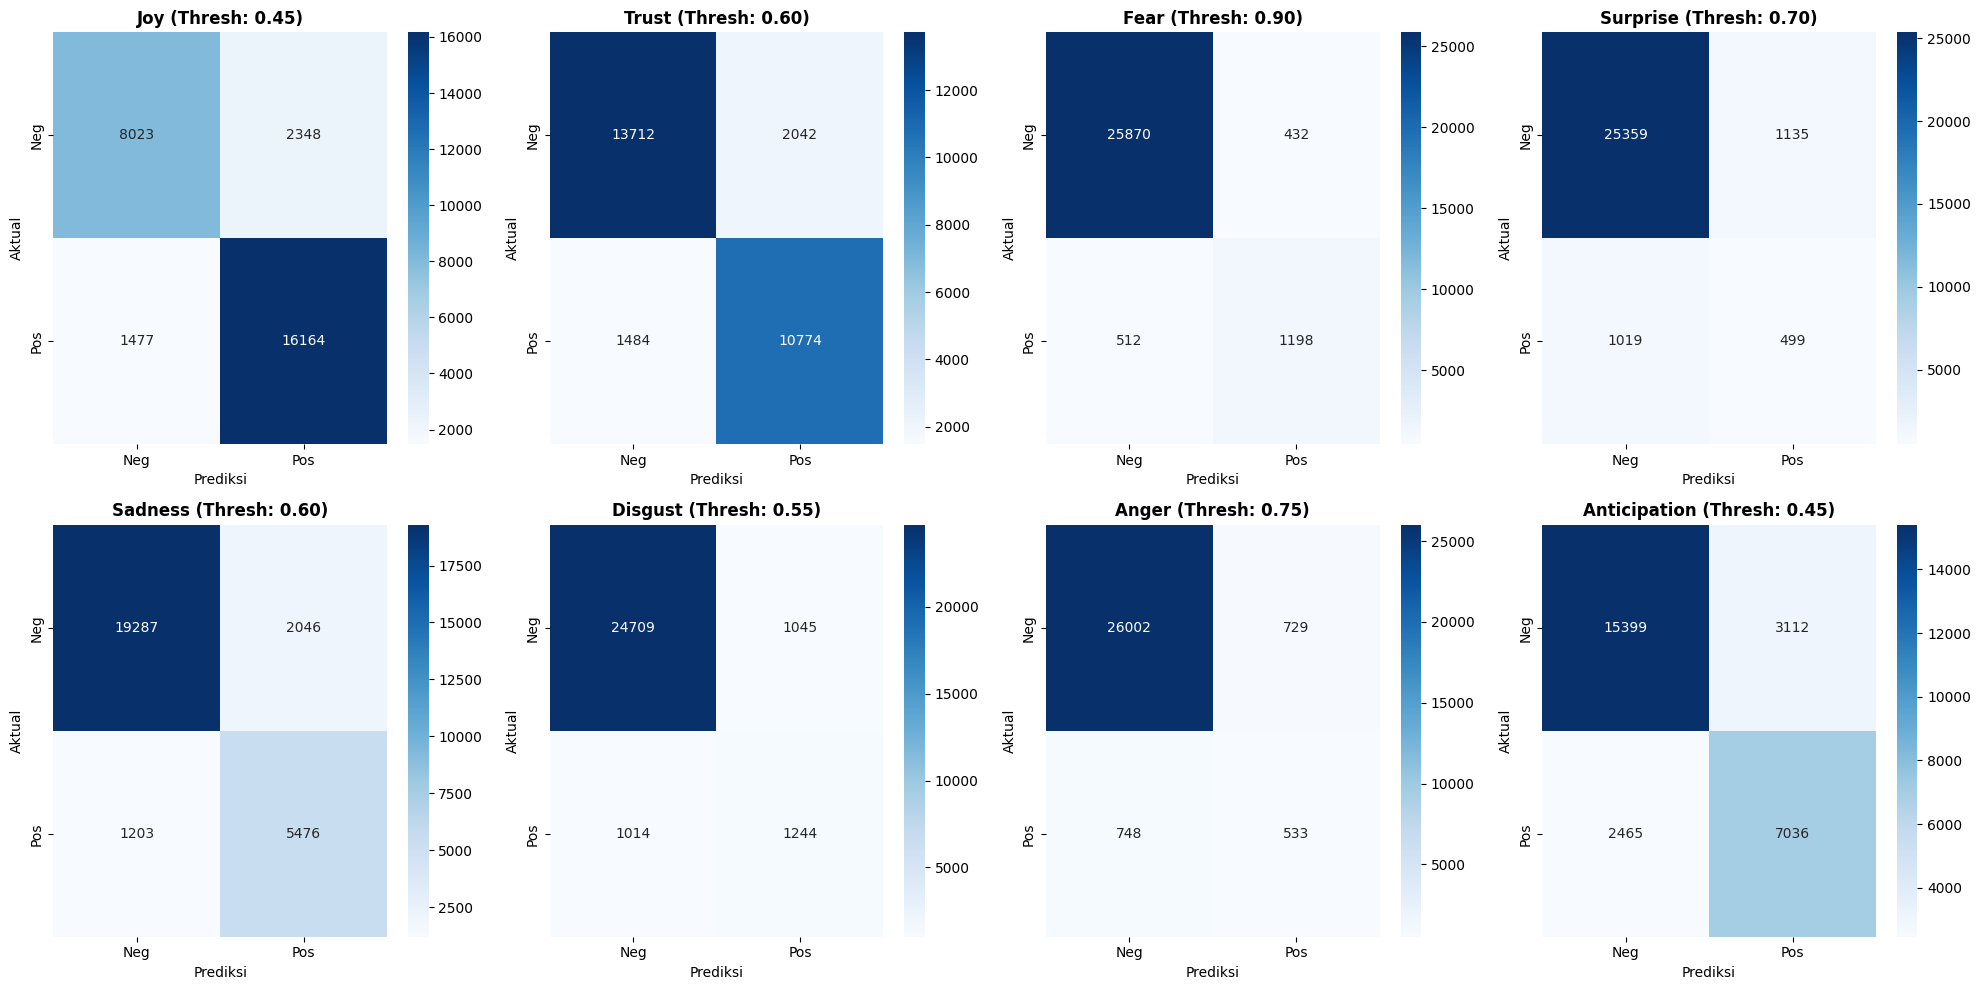


Confusion matrix plot saved to: ./fine_tuned_late_fusion_model/confusion_matrices.png
Detailed metrics per class saved to: ./fine_tuned_late_fusion_model/detailed_metrics_per_class.csv
Global metrics saved to: ./fine_tuned_late_fusion_model/global_metrics.txt
Classification report saved to: ./fine_tuned_late_fusion_model/classification_report.txt


In [15]:
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n=== 1. PENCARIAN DYNAMIC THRESHOLD (MENGGUNAKAN VALIDATION SET) ===")

# Ambil prediksi mentah (logits) dari data VALIDASI
val_output = trainer.predict(eval_dataset)
val_logits = val_output.predictions
val_labels = val_output.label_ids

# Ubah logits ke probabilitas (Sigmoid)
val_probs = torch.sigmoid(torch.tensor(val_logits)).numpy()

# Cari threshold terbaik untuk SETIAP label
best_thresholds = np.full(num_labels, 0.5)
search_range = np.arange(0.1, 0.95, 0.05)

print("Mengoptimalkan threshold per label...")
for i in range(num_labels):
    best_f1 = 0
    best_thresh = 0.5
    for thresh in search_range:
        preds = (val_probs[:, i] > thresh).astype(int)
        current_f1 = f1_score(val_labels[:, i], preds, zero_division=0)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_thresh = thresh

    best_thresholds[i] = best_thresh

# Tampilkan Threshold terpilih
thresh_df = pd.DataFrame({'Label': label_columns, 'Optimized Threshold': best_thresholds})
print(thresh_df)


print("\n=== 2. EVALUASI TEST SET (DENGAN DYNAMIC THRESHOLD) ===")

# Ambil prediksi mentah dari data TEST
test_output = trainer.predict(test_dataset)
test_probs = torch.sigmoid(torch.tensor(test_output.predictions)).numpy()
test_labels_true = test_output.label_ids

# Array untuk menyimpan prediksi final
final_test_preds = np.zeros_like(test_probs, dtype=int)

# Terapkan threshold yang sudah dioptimalkan
for i in range(num_labels):
    final_test_preds[:, i] = (test_probs[:, i] > best_thresholds[i]).astype(int)

# --- HITUNG METRIK ---

# 1. Metrik Global
global_acc = accuracy_score(test_labels_true, final_test_preds)
global_f1_macro = f1_score(test_labels_true, final_test_preds, average='macro')
global_f1_micro = f1_score(test_labels_true, final_test_preds, average='micro')

print(f"\n[Global Metrics]")
print(f"Accuracy (Exact Match): {global_acc:.4f}")
print(f"F1 Macro Average      : {global_f1_macro:.4f}")
print(f"F1 Micro Average      : {global_f1_micro:.4f}")

# 2. Metrik Per Kelas
f1_per_class = f1_score(test_labels_true, final_test_preds, average=None)
prec_per_class = precision_score(test_labels_true, final_test_preds, average=None, zero_division=0)
rec_per_class = recall_score(test_labels_true, final_test_preds, average=None, zero_division=0)

# Buat DataFrame Laporan
df_metrics = pd.DataFrame({
    'Label': label_columns,
    'Threshold': best_thresholds,
    'Precision': prec_per_class,
    'Recall': rec_per_class,
    'F1-Score': f1_per_class
})

print("\n[Detailed Metrics Per Class]")
print(df_metrics.round(4).to_string(index=False))

# 3. Tampilkan Classification Report standar (format teks)
print("\n--- SKLEARN CLASSIFICATION REPORT ---")
print(classification_report(test_labels_true, final_test_preds, target_names=label_columns, zero_division=0))

# --- VISUALISASI CONFUSION MATRIX ---
print("\n=== 3. VISUALISASI CONFUSION MATRIX ===")

# Siapkan grid plot (sesuaikan ukuran figsize jika perlu)
# Jika label ada 8, kita buat 2 baris x 4 kolom
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, label_name in enumerate(label_columns):
    # Hitung CM menggunakan prediksi yang sudah di-threshold
    cm = confusion_matrix(
        y_true=test_labels_true[:, i],
        y_pred=final_test_preds[:, i]
    )

    # Plot Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])

    axes[i].set_title(f"{label_name.title()} (Thresh: {best_thresholds[i]:.2f})", fontweight='bold')
    axes[i].set_xlabel('Prediksi')
    axes[i].set_ylabel('Aktual')

plt.tight_layout()
plt.show()


# save plot to drive
# --- Generate, Save, and Log Confusion Matrix Plot ---
final_model_path = "./fine_tuned_late_fusion_model"
os.makedirs(final_model_path, exist_ok=True)
cm_plot_path = os.path.join(final_model_path, "confusion_matrices.png")
fig.savefig(cm_plot_path)
print(f"\nConfusion matrix plot saved to: {cm_plot_path}")

# simpan laporan metrik ke CSV
metrics_csv_path = os.path.join(final_model_path, "detailed_metrics_per_class.csv")
df_metrics.to_csv(metrics_csv_path, index=False)
print(f"Detailed metrics per class saved to: {metrics_csv_path}")

# simpan laporan global metrik ke TXT
global_metrics_txt_path = os.path.join(final_model_path, "global_metrics.txt")
with open(global_metrics_txt_path, 'w') as f:
    f.write(f"Global Metrics:\n")
    f.write(f"Accuracy (Exact Match): {global_acc:.4f}\n")
    f.write(f"F1 Macro Average      : {global_f1_macro:.4f}\n")
    f.write(f"F1 Micro Average      : {global_f1_micro:.4f}\n")
print(f"Global metrics saved to: {global_metrics_txt_path}")

# simpan classification report ke TXT
classification_report_txt_path = os.path.join(final_model_path, "classification_report.txt")
with open(classification_report_txt_path, 'w') as f:
    f.write(classification_report(test_labels_true, final_test_preds, target_names=label_columns, zero_division=0))
print(f"Classification report saved to: {classification_report_txt_path}")

In [16]:
# --- TAMBAHAN: LOGGING MANUAL KE WANDB ---
import wandb

# Cek apakah W&B sedang aktif
if wandb.run is not None:
    print("\nMengirim hasil evaluasi Dynamic Threshold ke W&B...")

    # 1. Log Metrik Global (dengan suffix '_dynamic' agar beda dengan default)
    wandb.log({
        "test/accuracy_dynamic": accuracy_score(test_labels_true, final_test_preds),
        "test/f1_macro_dynamic": f1_score(test_labels_true, final_test_preds, average='macro'),
        "test/f1_micro_dynamic": f1_score(test_labels_true, final_test_preds, average='micro'),
    })

    # 2. Log Metrik Per Label & Threshold yang dipakai
    for i, label in enumerate(label_columns):
        wandb.log({
            f"test_per_class/f1_{label}": f1_score(test_labels_true[:, i], final_test_preds[:, i], zero_division=0),
            f"test_per_class/threshold_{label}": best_thresholds[i]
        })

    # 3. Log Hyperparameter Bobot (w1, w2) - Penting untuk tuning!
    # Mengakses atribut w1/w2 dari model (pastikan model masih ada di memori)
    if hasattr(model, 'w1') and hasattr(model, 'w2'):
        wandb.log({
            "hyperparams/weight_text (w1)": model.w1,
            "hyperparams/weight_emoji (w2)": model.w2
        })

    # 4. Log Gambar Confusion Matrix
    # 'fig' diambil dari plot matplotlib di kode sebelumnya
    wandb.log({"confusion_matrix_dynamic": wandb.Image(fig)})

    print("Log ke W&B berhasil.")
else:
    print("\nW&B run tidak terdeteksi. Hasil tidak di-upload.")


Mengirim hasil evaluasi Dynamic Threshold ke W&B...
Log ke W&B berhasil.


# LANGKAH 8: MENYIMPAN MODEL DAN TOKENIZER FINAL
## [MODIFIED] Menyimpan model yang sudah di-fine-tuning. Perhatikan bahwa ini hanya menyimpan state_dict dari model kustom kita.

In [ ]:
# --- LANGKAH 8: MENYIMPAN MODEL, TOKENIZER, DAN ARTIFAK FINAL ---
import os
import json
import torch
import shutil
import wandb
from google.colab import drive

# 1. Konfigurasi Path Penyimpanan Lokal
if not os.path.exists(final_model_path):
    os.makedirs(final_model_path)

print(f"Menyimpan model ke folder lokal: '{final_model_path}'...")

# 2. Simpan Model (State Dict)
# Karena ini Custom Model, kita simpan state_dict-nya agar aman
torch.save(model.state_dict(), os.path.join(final_model_path, "pytorch_model.bin"))

# 3. Simpan Tokenizer & Config
tokenizer.save_pretrained(final_model_path)
model.config.save_pretrained(final_model_path)

# 4. Simpan Dictionary Emoji (Penting untuk Inference nanti)
# Pastikan variabel 'emoji_to_id' dari langkah awal masih ada
if 'emoji_to_id' in globals():
    with open(os.path.join(final_model_path, "emoji_to_id.json"), 'w') as f:
        json.dump(emoji_to_id, f)
    print("Mapping emoji_to_id berhasil disimpan.")
else:
    print("Peringatan: Variabel 'emoji_to_id' tidak ditemukan. Mapping tidak disimpan.")

print("Model dan Tokenizer berhasil disimpan secara lokal.")

# 5. Logging ke WandB (Menutup Sesi)
if wandb.run is not None:
    print("\nMengirim metrik final ke WandB...")
    # Mengambil variabel metrik dari Langkah 7 (jika ada)
    try:
        wandb.log({
            "final/accuracy": global_acc,
            "final/f1_macro": global_f1_macro,
            "final/f1_micro": global_f1_micro
        })
        print("Metrik final terkirim.")
    except NameError:
        print("Variabel metrik (global_acc, dll) tidak ditemukan. Pastikan Langkah 7 sudah dijalankan.")

    wandb.finish()
    print("Sesi WandB ditutup.")

# 6. Simpan ke Google Drive (Opsional)
print("\n--- MENYALIN KE GOOGLE DRIVE ---")
try:
    drive.mount('/content/drive')

    # Path tujuan di Google Drive (Sesuaikan nama folder jika perlu)
    drive_save_path = "/content/drive/MyDrive/TEA Multi Modal Project/Model_v2/EF_Concat/run_5/"

    if not os.path.exists(drive_save_path):
        os.makedirs(drive_save_path)

    # Salin isi folder lokal ke Google Drive
    shutil.copytree(final_model_path, drive_save_path, dirs_exist_ok=True)
    print(f"Sukses! Model berhasil disalin ke: {drive_save_path}")

except Exception as e:
    print(f"Gagal menyalin ke Google Drive: {e}")

Menyimpan model ke folder lokal: './fine_tuned_late_fusion_model'...
Mapping emoji_to_id berhasil disimpan.
Model dan Tokenizer berhasil disimpan secara lokal.

--- MENYALIN KE GOOGLE DRIVE ---
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sukses! Model berhasil disalin ke: /content/drive/MyDrive/fine_tuned_indobert_early_fusion_concat/training_run_latest
